In [8]:
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [9]:
print("Tensorflow vesion: ",tf.__version__)

Tensorflow vesion:  2.20.0


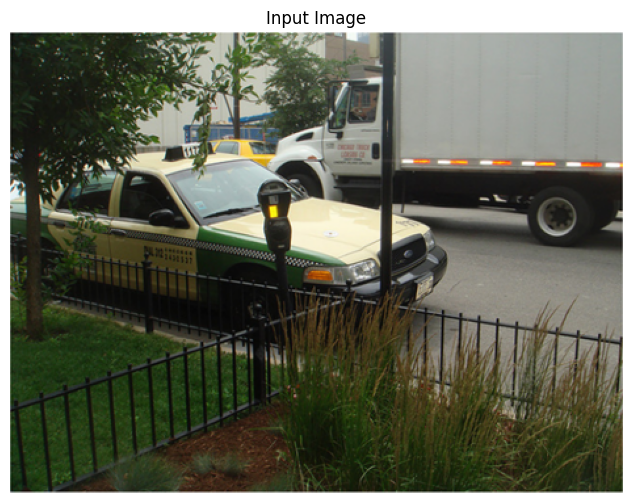

In [11]:
img = cv2.imread("/content/test.PNG")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8,6))
plt.imshow(img_rgb)
plt.title("Input Image")
plt.axis('off')
plt.show()

In [12]:
model=hub.load("https://tfhub.dev/tensorflow/ssd_mobilenet_v2/2")

In [13]:
image=tf.convert_to_tensor(img_rgb)
image=image[tf.newaxis,...]

In [15]:
result=model(image)
boxes=result["detection_boxes"][0].numpy()
scores=result["detection_scores"][0].numpy()
classes=result["detection_classes"][0].numpy()

In [16]:
h,w,_ = img.shape
for i in range(5):
  if scores[i]>0.5:
    y1,x1,y2,x2=boxes[i]
    cv2.rectangle(img,(int(x1*w),int(y1*h)),(int(x2*w),int(y2*h)),(0,255,0),2)

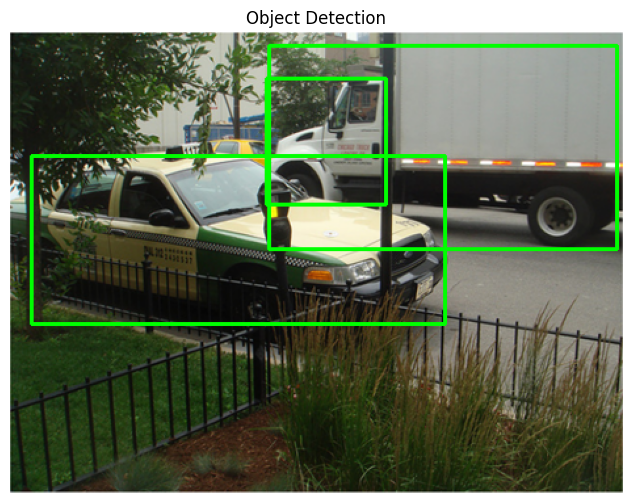

In [18]:
img_rgb=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8,6))
plt.imshow(img_rgb)
plt.title("Object Detection")
plt.axis('off')
plt.show()